# Namma Yatri - Data Analytics Project

<img src="https://nammayatri.in/img/driverOnboard-NammaYatri.png" height="450">

## Overview
This project focuses on analyzing the data from the Namma Yatri passenger services platform, aiming to gain insights into various aspects such as trips, searches, driver earnings, and booking locations. The analysis is performed using Python queries and visualized through graphs using Power BI.


## ***1. Know Your Data***

### Import Libraries

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Load Nammayatri Datasets**

In [163]:
df_assembly = pd.read_csv('nammayatri_assembly.csv')
df_date = pd.read_csv('nammayatri_date.csv')
df_payment = pd.read_csv('nammayatri_payment.csv')
df_tripdetails = pd.read_csv('nammayatri_tripdetails.csv')
df_trips = pd.read_csv('nammayatri_trips.csv')

### Dataset First View

In [164]:
df_assembly.head()

,ID,Assembly
0,1,Mahadevapura
1,2,B. T. M. Layout
2,3,Bommanahalli
3,4,C. V. Raman Nagar
4,5,Shanti Nagar


In [167]:
df_date.head()

,id,duration
0,1,0-1
1,2,2-Jan
2,3,3-Feb
3,4,4-Mar
4,5,5-Apr


In [169]:
# Rename duration column to trip duration
df_date.rename(columns={'duration':'trip_duration'}, inplace=True)

In [171]:
df_date.head()

,id,trip_duration
0,1,0-1
1,2,2-Jan
2,3,3-Feb
3,4,4-Mar
4,5,5-Apr


In [173]:
df_payment.head()

,id,method
0,1,cash
1,2,upi
2,3,debit card
3,4,credit card


In [175]:
df_tripdetails.head()

,tripid,loc_from,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride
0,1,16,1,1,1,1,1,1,1,1
1,2,24,1,1,1,1,1,1,1,1
2,3,18,1,1,1,1,1,1,1,1
3,4,28,1,1,1,1,1,1,1,1
4,5,19,1,1,1,1,1,1,1,1


In [177]:
df_trips.head()

,tripid,faremethod,fare,loc_from,loc_to,driverid,custid,distance,duration
0,1,2,776,16,8,7,98,23,20
1,2,2,1479,24,33,1,76,26,15
2,3,4,152,18,32,6,45,3,24
3,4,3,153,28,14,28,40,5,4
4,5,2,366,19,27,27,59,5,2


In [179]:
# Droping loc_from column from tripdetails table because it will create a exact copy table when we will merge with trips table
df_tripdetails = df_tripdetails.drop(columns = 'loc_from')

In [181]:
df_tripdetails.head()

,tripid,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride
0,1,1,1,1,1,1,1,1,1
1,2,1,1,1,1,1,1,1,1
2,3,1,1,1,1,1,1,1,1
3,4,1,1,1,1,1,1,1,1
4,5,1,1,1,1,1,1,1,1


In [183]:
# Merging table trips and tripdetails using left join 
df = df_trips.merge(df_tripdetails, on='tripid', how='left')

In [185]:
df.head()

,tripid,faremethod,fare,loc_from,loc_to,driverid,custid,distance,duration,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride
0,1,2,776,16,8,7,98,23,20,1,1,1,1,1,1,1,1
1,2,2,1479,24,33,1,76,26,15,1,1,1,1,1,1,1,1
2,3,4,152,18,32,6,45,3,24,1,1,1,1,1,1,1,1
3,4,3,153,28,14,28,40,5,4,1,1,1,1,1,1,1,1
4,5,2,366,19,27,27,59,5,2,1,1,1,1,1,1,1,1


In [187]:
#Merging new dataframe with payment table
df = df.merge(df_payment, left_on='faremethod', right_on='id', how='left')

In [189]:
df.head()

,tripid,faremethod,fare,loc_from,loc_to,driverid,custid,distance,duration,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride,id,method
0,1,2,776,16,8,7,98,23,20,1,1,1,1,1,1,1,1,2,upi
1,2,2,1479,24,33,1,76,26,15,1,1,1,1,1,1,1,1,2,upi
2,3,4,152,18,32,6,45,3,24,1,1,1,1,1,1,1,1,4,credit card
3,4,3,153,28,14,28,40,5,4,1,1,1,1,1,1,1,1,3,debit card
4,5,2,366,19,27,27,59,5,2,1,1,1,1,1,1,1,1,2,upi


In [191]:
# Droping column id because it is the exact copy of column faremethod
df = df.drop(columns = 'id')

In [193]:
df.head()

,tripid,faremethod,fare,loc_from,loc_to,driverid,custid,distance,duration,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride,method
0,1,2,776,16,8,7,98,23,20,1,1,1,1,1,1,1,1,upi
1,2,2,1479,24,33,1,76,26,15,1,1,1,1,1,1,1,1,upi
2,3,4,152,18,32,6,45,3,24,1,1,1,1,1,1,1,1,credit card
3,4,3,153,28,14,28,40,5,4,1,1,1,1,1,1,1,1,debit card
4,5,2,366,19,27,27,59,5,2,1,1,1,1,1,1,1,1,upi


In [195]:
# Merging main dataframe with date table using left join
df = df.merge(df_date, left_on='duration', right_on='id', how='left')

In [197]:
df.head()

,tripid,faremethod,fare,loc_from,loc_to,driverid,custid,distance,duration,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride,method,id,trip_duration
0,1,2,776,16,8,7,98,23,20,1,1,1,1,1,1,1,1,upi,20,19-20
1,2,2,1479,24,33,1,76,26,15,1,1,1,1,1,1,1,1,upi,15,14-15
2,3,4,152,18,32,6,45,3,24,1,1,1,1,1,1,1,1,credit card,24,23-24
3,4,3,153,28,14,28,40,5,4,1,1,1,1,1,1,1,1,debit card,4,4-Mar
4,5,2,366,19,27,27,59,5,2,1,1,1,1,1,1,1,1,upi,2,2-Jan


In [199]:
# Droping column id because it is the exact copy of column duration
df = df.drop(columns = 'id')

In [201]:
df.head()

,tripid,faremethod,fare,loc_from,loc_to,driverid,custid,distance,duration,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride,method,trip_duration
0,1,2,776,16,8,7,98,23,20,1,1,1,1,1,1,1,1,upi,19-20
1,2,2,1479,24,33,1,76,26,15,1,1,1,1,1,1,1,1,upi,14-15
2,3,4,152,18,32,6,45,3,24,1,1,1,1,1,1,1,1,credit card,23-24
3,4,3,153,28,14,28,40,5,4,1,1,1,1,1,1,1,1,debit card,4-Mar
4,5,2,366,19,27,27,59,5,2,1,1,1,1,1,1,1,1,upi,2-Jan


In [203]:
# creating exact copy assembly because it will help us wen we join with main dataframe
df1_assembly = df_assembly

In [205]:
df1_assembly.head()

,ID,Assembly
0,1,Mahadevapura
1,2,B. T. M. Layout
2,3,Bommanahalli
3,4,C. V. Raman Nagar
4,5,Shanti Nagar


In [207]:
# Rename the column Assembly to assembly 2
df1_assembly.rename(columns={'Assembly':'Assembly2'})

,ID,Assembly2
0,1,Mahadevapura
1,2,B. T. M. Layout
2,3,Bommanahalli
3,4,C. V. Raman Nagar
4,5,Shanti Nagar
5,6,Bangalore South
6,7,Krishnarajapuram
7,8,Byatarayanapura
8,9,Jayanagar
9,10,Shivajinagar


In [209]:
# merging table Assembly with main data frame
df = df.merge(df_assembly, left_on='loc_from', right_on='ID', how='left')

In [211]:
df.head()

,tripid,faremethod,fare,loc_from,loc_to,driverid,custid,distance,duration,searches,...,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride,method,trip_duration,ID,Assembly
0,1,2,776,16,8,7,98,23,20,1,...,1,1,1,1,1,1,upi,19-20,16,Gandhi Nagar
1,2,2,1479,24,33,1,76,26,15,1,...,1,1,1,1,1,1,upi,14-15,24,Vijay Nagar
2,3,4,152,18,32,6,45,3,24,1,...,1,1,1,1,1,1,credit card,23-24,18,Yeshwantpur
3,4,3,153,28,14,28,40,5,4,1,...,1,1,1,1,1,1,debit card,4-Mar,28,Chamrajpet
4,5,2,366,19,27,27,59,5,2,1,...,1,1,1,1,1,1,upi,2-Jan,19,Basavanagudi


In [213]:
#merging other assembly table with main dataframe
df = df.merge(df1_assembly, left_on='loc_to', right_on='ID', how='left')

In [215]:
df.head()

,tripid,faremethod,fare,loc_from,loc_to,driverid,custid,distance,duration,searches,...,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride,method,trip_duration,ID_x,Assembly_x,ID_y,Assembly_y
0,1,2,776,16,8,7,98,23,20,1,...,1,1,1,1,upi,19-20,16,Gandhi Nagar,8,Byatarayanapura
1,2,2,1479,24,33,1,76,26,15,1,...,1,1,1,1,upi,14-15,24,Vijay Nagar,33,Magadi
2,3,4,152,18,32,6,45,3,24,1,...,1,1,1,1,credit card,23-24,18,Yeshwantpur,32,Devanahalli
3,4,3,153,28,14,28,40,5,4,1,...,1,1,1,1,debit card,4-Mar,28,Chamrajpet,14,Malleshwaram
4,5,2,366,19,27,27,59,5,2,1,...,1,1,1,1,upi,2-Jan,19,Basavanagudi,27,Anekal


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 983 entries, 0 to 982
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   tripid                  983 non-null    int64 
 1   faremethod              983 non-null    int64 
 2   fare                    983 non-null    int64 
 3   loc_from                983 non-null    int64 
 4   loc_to                  983 non-null    int64 
 5   driverid                983 non-null    int64 
 6   custid                  983 non-null    int64 
 7   distance                983 non-null    int64 
 8   duration                983 non-null    int64 
 9   searches                983 non-null    int64 
 10  searches_got_estimate   983 non-null    int64 
 11  searches_for_quotes     983 non-null    int64 
 12  searches_got_quotes     983 non-null    int64 
 13  customer_not_cancelled  983 non-null    int64 
 14  driver_not_cancelled    983 non-null    int64 
 15  otp_en

In [219]:
# droping column loc_from, loc_to, ID_X, Id_y because we don't need this numerical column
df = df.drop(columns=['loc_from','loc_to','ID_x','ID_y'])

In [221]:
df.head()

,tripid,faremethod,fare,driverid,custid,distance,duration,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride,method,trip_duration,Assembly_x,Assembly_y
0,1,2,776,7,98,23,20,1,1,1,1,1,1,1,1,upi,19-20,Gandhi Nagar,Byatarayanapura
1,2,2,1479,1,76,26,15,1,1,1,1,1,1,1,1,upi,14-15,Vijay Nagar,Magadi
2,3,4,152,6,45,3,24,1,1,1,1,1,1,1,1,credit card,23-24,Yeshwantpur,Devanahalli
3,4,3,153,28,40,5,4,1,1,1,1,1,1,1,1,debit card,4-Mar,Chamrajpet,Malleshwaram
4,5,2,366,27,59,5,2,1,1,1,1,1,1,1,1,upi,2-Jan,Basavanagudi,Anekal


In [223]:
# Rename Assembly_x to pickup location and Assembly_y to drop location
df = df.rename(columns={'Assembly_x':'Pickup_location','Assembly_y':'Drop_location'})

In [225]:
# Droping column faremethod
df = df.drop(columns=['faremethod'])

In [227]:
#renaming method to Faremetod
df = df.rename(columns={'method':'Faremethod'})

In [259]:
# Creating new Column Route in the main dataframe
df['route'] = df['Pickup_location'] + " → " + df['Drop_location']

In [369]:
df

,tripid,fare,driverid,custid,distance,duration,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,...,driver_not_cancelled,otp_entered,end_ride,Faremethod,trip_duration,Pickup_location,Drop_location,fare_per_km,route,payment_method
0,1,776,7,98,23,20,1,1,1,1,...,1,1,1,upi,19-20,Gandhi Nagar,Byatarayanapura,33.739130,Gandhi Nagar → Byatarayanapura,NaN
1,2,1479,1,76,26,15,1,1,1,1,...,1,1,1,upi,14-15,Vijay Nagar,Magadi,56.884615,Vijay Nagar → Magadi,NaN
2,3,152,6,45,3,24,1,1,1,1,...,1,1,1,credit card,23-24,Yeshwantpur,Devanahalli,50.666667,Yeshwantpur → Devanahalli,NaN
3,4,153,28,40,5,4,1,1,1,1,...,1,1,1,debit card,4-Mar,Chamrajpet,Malleshwaram,30.600000,Chamrajpet → Malleshwaram,NaN
4,5,366,27,59,5,2,1,1,1,1,...,1,1,1,upi,2-Jan,Basavanagudi,Anekal,73.200000,Basavanagudi → Anekal,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,979,1245,27,48,21,20,1,1,1,1,...,1,1,1,credit card,19-20,Channapatna,Devanahalli,59.285714,Channapatna → Devanahalli,NaN
979,980,809,22,68,25,14,1,1,1,1,...,1,1,1,cash,13-14,Dasarahalli,Shanti Nagar,32.360000,Dasarahalli → Shanti Nagar,NaN
980,981,695,3,29,6,20,1,1,1,1,...,1,1,1,debit card,19-20,Shanti Nagar,Sarvagnanagar,115.833333,Shanti Nagar → Sarvagnanagar,NaN
981,982,1499,20,13,22,23,1,1,1,1,...,1,1,1,upi,22-23,C. V. Raman Nagar,Pulakeshinagar,68.136364,C. V. Raman Nagar → Pulakeshinagar,NaN


##**About the Dataset – Nammyatri trips**

*   This Nammayatri dataset contains nearly 982 observations from India , with 21 columns of data.

*   The Data includes both categorical and numeric values, providing a diverse range of information about the trips.

*   This Dataset may be useful for analyzing trends and patterns in the Nammayatri market in India and also gain insights into the preferences and behavior of Nammayatri trips in the area.

*   This dataset contains information about Nammayatri trips in India. By analyzing this data, you may be able to understand the trends and patterns of Nammayatri use in the India.

# **Data Exploration and Data Cleaning**

### Dataset Information

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 983 entries, 0 to 982
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tripid                  983 non-null    int64  
 1   fare                    983 non-null    int64  
 2   driverid                983 non-null    int64  
 3   custid                  983 non-null    int64  
 4   distance                983 non-null    int64  
 5   duration                983 non-null    int64  
 6   searches                983 non-null    int64  
 7   searches_got_estimate   983 non-null    int64  
 8   searches_for_quotes     983 non-null    int64  
 9   searches_got_quotes     983 non-null    int64  
 10  customer_not_cancelled  983 non-null    int64  
 11  driver_not_cancelled    983 non-null    int64  
 12  otp_entered             983 non-null    int64  
 13  end_ride                983 non-null    int64  
 14  Faremethod              983 non-null    ob

### Dataset Rows & Columns count

In [307]:
df.shape

(983, 20)

### Missing Values/Null Values

In [303]:
df.isnull().sum()

tripid                    0
fare                      0
driverid                  0
custid                    0
distance                  0
duration                  0
searches                  0
searches_got_estimate     0
searches_for_quotes       0
searches_got_quotes       0
customer_not_cancelled    0
driver_not_cancelled      0
otp_entered               0
end_ride                  0
Faremethod                0
trip_duration             0
Pickup_location           0
Drop_location             0
fare_per_km               0
route                     0
dtype: int64

### Duplicate Values

In [305]:
df.duplicated().sum()

0

**so, there is no any duplicate rows in Dataset**

### Check Unique Values for each variable.

In [241]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print(f"No. of unique values in {i} is {df[i].nunique()}.")

No. of unique values in tripid is 983.
No. of unique values in fare is 709.
No. of unique values in driverid is 30.
No. of unique values in custid is 99.
No. of unique values in distance is 26.
No. of unique values in duration is 24.
No. of unique values in searches is 1.
No. of unique values in searches_got_estimate is 1.
No. of unique values in searches_for_quotes is 1.
No. of unique values in searches_got_quotes is 1.
No. of unique values in customer_not_cancelled is 1.
No. of unique values in driver_not_cancelled is 1.
No. of unique values in otp_entered is 1.
No. of unique values in end_ride is 1.
No. of unique values in Faremethod is 4.
No. of unique values in trip_duration is 24.
No. of unique values in Pickup_location is 37.
No. of unique values in Drop_location is 37.


# **Describe the Dataset and removing outliers**

In [309]:
df.describe()

,tripid,fare,driverid,custid,distance,duration,searches,searches_got_estimate,searches_for_quotes,searches_got_quotes,customer_not_cancelled,driver_not_cancelled,otp_entered,end_ride,fare_per_km
count,983.000000,983.000000,983.000000,983.000000,983.000000,983.000000,983.0,983.0,983.0,983.0,983.0,983.0,983.0,983.0,983.000000
mean,492.000000,764.336724,15.491353,49.787386,14.392675,12.344863,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,84.998239
std,283.911958,423.846617,8.738197,28.499983,7.404960,6.881903,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,103.477027
min,1.000000,44.000000,1.000000,1.000000,2.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.880000
25%,246.500000,401.500000,8.000000,25.000000,8.000000,7.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,27.480159
50%,492.000000,740.000000,15.000000,48.000000,14.000000,12.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,52.500000
75%,737.500000,1138.000000,23.000000,74.000000,21.000000,18.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,97.662393
max,983.000000,1500.000000,30.000000,99.000000,27.000000,24.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,739.500000


In [243]:
# Date Range
df['trip_duration'].min(), df['trip_duration'].max()

('0-1', '9-Aug')

**Note** - Minimum trip duration is 0-9 and Maximum trip duration is 9-10

In [245]:
# Top Pickup Location
df['Pickup_location'].value_counts().head(10)

Pickup_location
Ramanagaram            39
Yeshwantpur            36
Dasarahalli            33
Bangalore South        33
Gandhi Nagar           32
Rajarajeshwarinagar    32
Chamrajpet             31
Jayanagar              31
Hebbal                 31
Channapatna            30
Name: count, dtype: int64

**Note** - Ramanagaram is the top pickup location.

In [247]:
# top drop location
df['Drop_location'].value_counts().head(10)

Drop_location
Hoskote          37
Chamrajpet       36
Kanakapura       34
Vijay Nagar      33
Yelahanka        32
Shanti Nagar     31
Dasarahalli      31
Gandhi Nagar     30
Sarvagnanagar    29
Doddaballapur    29
Name: count, dtype: int64

**Note** - Haskote is the top drop location.

In [251]:
# Average distance per pickup location
df.groupby('Pickup_location')['distance'].mean().sort_values(ascending=False)

Pickup_location
Mahadevapura           18.192308
Bommanahalli           16.517241
Gandhi Nagar           16.156250
Rajarajeshwarinagar    15.968750
Malleshwaram           15.777778
Jayanagar              15.709677
Padmanabhanagar        15.615385
Chamrajpet             15.419355
Channapatna            15.400000
Basavanagudi           15.392857
Other Assemblies       15.133333
Vijay Nagar            14.961538
Shanti Nagar           14.772727
Govindraj Nagar        14.766667
Kanakapura             14.518519
Mahalakshmi Layout     14.500000
Ramanagaram            14.461538
Devanahalli            14.375000
Byatarayanapura        14.315789
Sarvagnanagar          14.280000
Magadi                 14.045455
Yeshwantpur            13.805556
Shivajinagar           13.777778
Krishnarajapuram       13.750000
Pulakeshinagar         13.714286
Bangalore South        13.696970
Dasarahalli            13.575758
Rajaji Nagar           13.526316
B. T. M. Layout        13.384615
Anekal                 13.3

**Note** - This shows us average distance cover by each location.

In [253]:
# Fare distribution
df['fare'].describe()

count     983.000000
mean      764.336724
std       423.846617
min        44.000000
25%       401.500000
50%       740.000000
75%      1138.000000
max      1500.000000
Name: fare, dtype: float64

In [255]:
# Average fare per KM
df['fare_per_km'] = df['fare']/df['distance']
df['fare_per_km'].mean()

84.99823911829071

In [256]:
# Fare Metod Usage
df['Faremethod'].value_counts()

Faremethod
credit card    262
upi            243
debit card     243
cash           235
Name: count, dtype: int64

**Note** - This shows that most payment is done by Credit card.

In [261]:
df[['Pickup_location', 'Drop_location', 'route']].head()

,Pickup_location,Drop_location,route
0,Gandhi Nagar,Byatarayanapura,Gandhi Nagar → Byatarayanapura
1,Vijay Nagar,Magadi,Vijay Nagar → Magadi
2,Yeshwantpur,Devanahalli,Yeshwantpur → Devanahalli
3,Chamrajpet,Malleshwaram,Chamrajpet → Malleshwaram
4,Basavanagudi,Anekal,Basavanagudi → Anekal


In [273]:
# Most trips cover by wich route
route_trips = (
    df.groupby('route')
      .size()
      .reset_index(name='total_trips')
      .sort_values(by='total_trips', ascending=False)
)

route_trips.head(10)

,route,total_trips
587,Ramanagaram → Shanti Nagar,5
265,Gandhi Nagar → Yelahanka,5
488,Other Assemblies → Vijay Nagar,4
453,Malleshwaram → Vijay Nagar,4
585,Ramanagaram → Rajaji Nagar,4
702,Yeshwantpur → Shivajinagar,4
656,Vijay Nagar → Malleshwaram,4
464,Nelamangala → Pulakeshinagar,4
418,Mahadevapura → Yelahanka,4
304,Hebbal → Sarvagnanagar,4


**Note** - Ramanagaram to Shanti nagar is the most used route.

In [277]:
# Most Revenue came from which route
route_revenue = (
    df.groupby('route')['fare']
      .sum()
      .reset_index(name='total_revenue')
      .sort_values(by='total_revenue', ascending=False)
)

route_revenue.head(10)

,route,total_revenue
695,Yeshwantpur → Kanakapura,4923
304,Hebbal → Sarvagnanagar,4385
587,Ramanagaram → Shanti Nagar,4192
681,Yelahanka → Shanti Nagar,4082
702,Yeshwantpur → Shivajinagar,3906
356,Kanakapura → Krishnarajapuram,3716
605,Sarvagnanagar → Rajaji Nagar,3641
42,Bangalore South → Kanakapura,3452
493,Padmanabhanagar → Chamrajpet,3270
292,Hebbal → Chamrajpet,3147


In [392]:
# Avg fare, avg distance coverde by each route
route_stats = (
    df.groupby('route')
      .agg(
          avg_fare=('fare', 'mean'),
          avg_distance=('distance', 'mean'),
          trips=('tripid', 'count')
      )
      .reset_index()
)

route_stats.head(10)

,route,avg_fare,avg_distance,trips
0,Anekal → Anekal,51.000000,5.000000,1
1,Anekal → Chamrajpet,689.000000,3.000000,1
2,Anekal → Channapatna,1208.000000,11.000000,1
3,Anekal → Dasarahalli,1198.000000,19.000000,1
4,Anekal → Doddaballapur,1214.000000,15.000000,1
5,Anekal → Gandhi Nagar,1115.500000,12.000000,2
6,Anekal → Govindraj Nagar,1212.000000,7.000000,1
7,Anekal → Hebbal,760.333333,17.666667,3
8,Anekal → Hoskote,648.500000,24.000000,2
9,Anekal → Jayanagar,1068.000000,23.000000,1


In [287]:
# Payment method use by each route
pd.crosstab(df['route'], df['Faremethod']).head()

Faremethod,cash,credit card,debit card,upi
route,,,,
Anekal → Anekal,1,0,0,0
Anekal → Chamrajpet,0,1,0,0
Anekal → Channapatna,0,1,0,0
Anekal → Dasarahalli,0,1,0,0
Anekal → Doddaballapur,0,0,0,1


In [291]:
# Cancel by customer, driver by cancel in each route
route_cancel = (
    df.groupby('route')
      .agg(
          customer_cancel_rate=('customer_not_cancelled', lambda x: 1 - x.mean()),
          driver_cancel_rate=('driver_not_cancelled', lambda x: 1 - x.mean())
      )
      .reset_index()
)
route_cancel.head()

,route,customer_cancel_rate,driver_cancel_rate
0,Anekal → Anekal,0.0,0.0
1,Anekal → Chamrajpet,0.0,0.0
2,Anekal → Channapatna,0.0,0.0
3,Anekal → Dasarahalli,0.0,0.0
4,Anekal → Doddaballapur,0.0,0.0


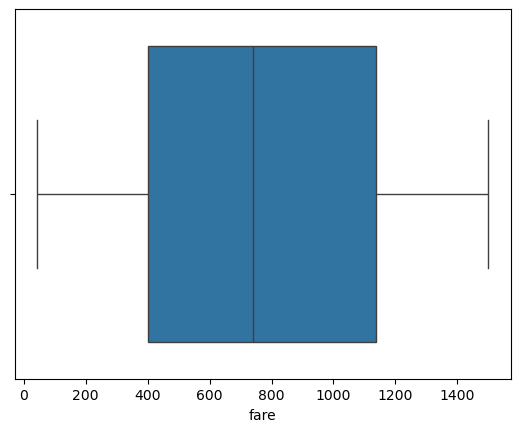

In [265]:
#Checking outliers
sns.boxplot(x = df['fare'])

plt.show()

**Note** - price column is very important so we have to find big outliers in important columns first.

---

# **Data Visualization**


# **Univariate visual**


   **(1) Distribution Of Nammayatri Fare**

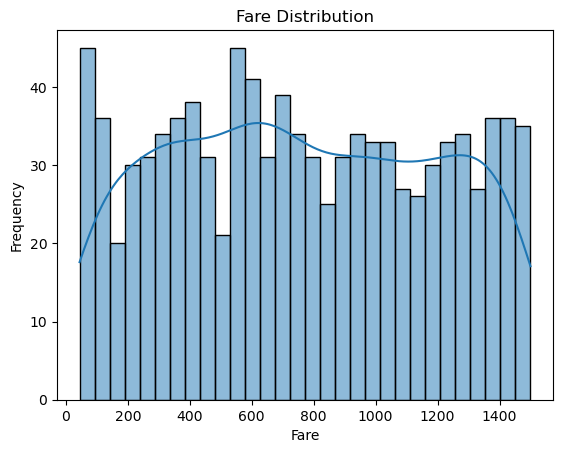

In [267]:
# Fare distribution
plt.figure()
sns.histplot(df['fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

**Note** - The fare distribution shows a wide range of values with a slight right skew. Most trips fall within lower and mid-range fares, while a small number of high-fare trips exist. The presence of multiple peaks suggests fare clustering, likely influenced by distance ranges and pricing slabs. This indicates that short and medium-distance trips dominate overall demand.


   **(3) Distribution Of Paymnet method**

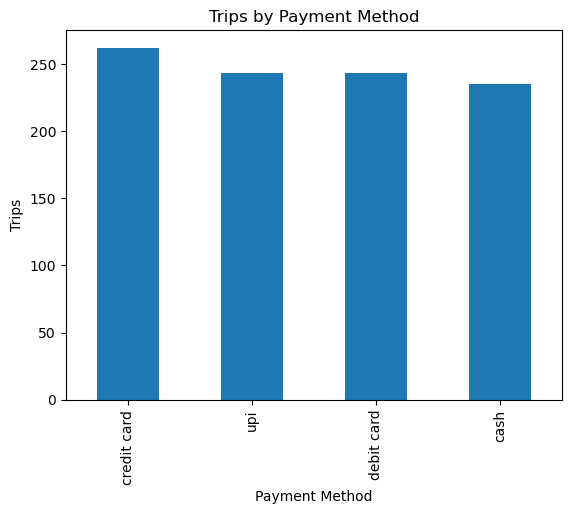

In [113]:
# Payment method Distribution
payment_counts = df['Faremethod'].value_counts()

plt.figure()
payment_counts.plot(kind='bar')
plt.title("Trips by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Trips")
plt.show()

**Note** - The bar chart shows the distribution of trips across different payment methods. Credit card emerges as the most frequently used payment option, followed closely by UPI and debit card. Cash transactions are comparatively lower, indicating a strong preference for digital payment methods among users


   **(4) Distribution Of trip duration**

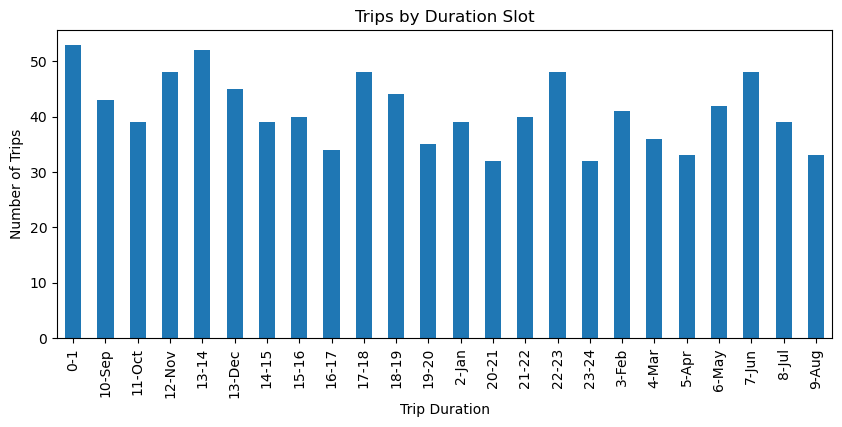

In [271]:
plt.figure(figsize=(10,4))
df['trip_duration'].value_counts().sort_index().plot(kind='bar')
plt.title("Trips by Duration Slot")
plt.xlabel("Trip Duration")
plt.ylabel("Number of Trips")
plt.show()

**Note** - The bar chart illustrates the distribution of trips across different duration slots. Trips are fairly evenly spread throughout the duration categories, with slightly higher frequencies in short and medium duration slots. The absence of extreme peaks indicates consistent demand and stable usage patterns across time intervals


   **(5) Top 10 count of Pickup location**

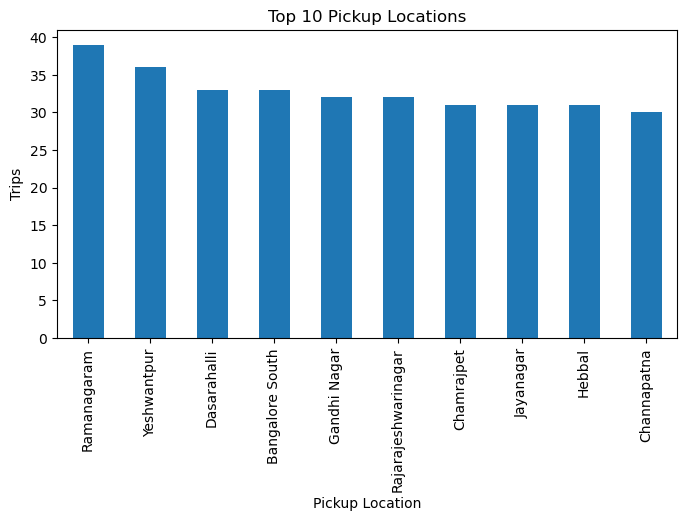

In [147]:
top_pickups = df['Pickup_location'].value_counts().head(10)

plt.figure(figsize=(8,4))
top_pickups.plot(kind='bar')
plt.title("Top 10 Pickup Locations")
plt.xlabel("Pickup Location")
plt.ylabel("Trips")
plt.show()

**Note** - The bar chart displays the top 10 pickup locations based on trip counts. Ramanagaram and Yeshwantpur emerge as the highest demand areas, indicating concentrated ride activity. The relatively balanced distribution among the top locations suggests multiple demand hubs across the city


   **(6) Top 10 count of drop location**

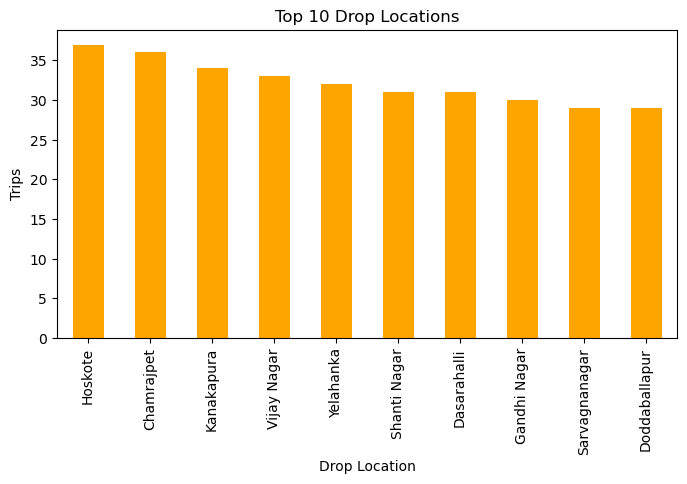

In [149]:
top_drops = df['Drop_location'].value_counts().head(10)

plt.figure(figsize=(8,4))
top_drops.plot(kind='bar', color='orange')
plt.title("Top 10 Drop Locations")
plt.xlabel("Drop Location")
plt.ylabel("Trips")
plt.show()

**Note** - “The bar chart presents the top 10 drop locations based on trip counts. Hoskote and Chamrajpet emerge as major destination areas. The difference between pickup and drop location rankings indicates directional commuting patterns, where trips often originate in commercial hubs and end in residential or suburban regions.

# **Biivariate visual**


   **(1) Distance vs Fare**

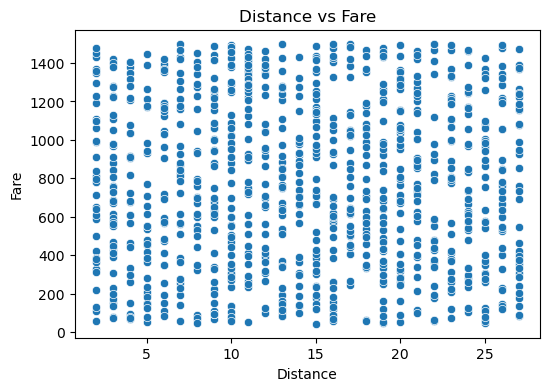

In [143]:
# Distance vs Fare
plt.figure(figsize=(6,4))
sns.scatterplot(x='distance', y='fare', data=df)
plt.title("Distance vs Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.show()

**Note** - The scatter plot illustrates the relationship between trip distance and fare. A positive correlation is observed, indicating that fares generally increase with distance. However, fare variability at the same distance suggests the influence of additional factors such as duration and route. Vertical clustering is observed due to discrete distance values.


   **(2) Faremethod by Fare**

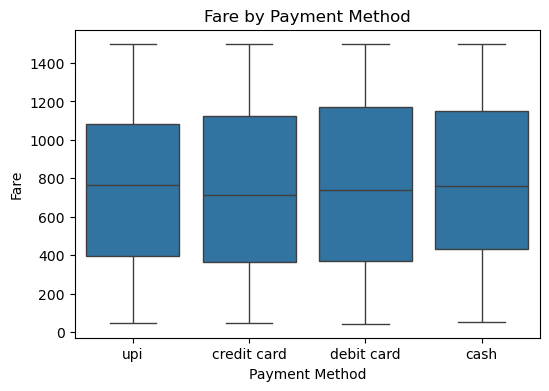

In [145]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Faremethod', y='fare', data=df)
plt.title("Fare by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.show()

**Note** - The box plot compares fare distributions across different payment methods. The median fares and interquartile ranges are similar for all methods, indicating that pricing is consistent and independent of the payment option used. High-fare trips are observed across all payment methods, suggesting uniform pricing behavior.


   **(3) Route vs total trips**

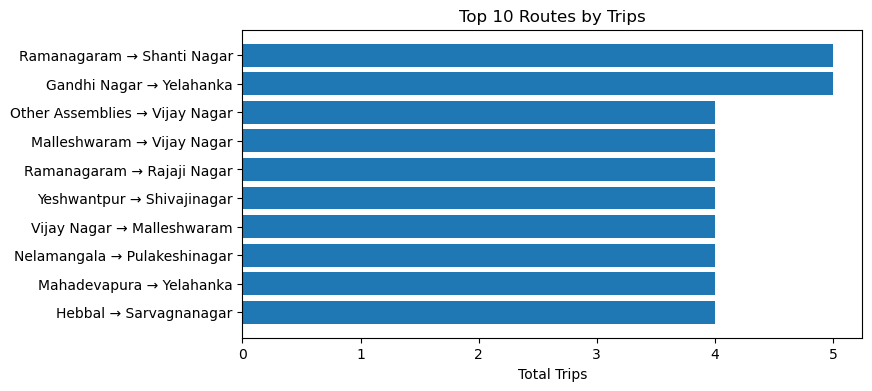

In [283]:
top_routes = route_trips.head(10)

plt.figure(figsize=(8,4))
plt.barh(top_routes['route'], top_routes['total_trips'])
plt.xlabel("Total Trips")
plt.title("Top 10 Routes by Trips")
plt.gca().invert_yaxis()
plt.show()

**Note** - The chart highlights the top 10 routes based on trip frequency. Routes such as Ramanagaram to Shanti Nagar and Gandhi Nagar to Yelahanka emerge as high-demand corridors. The relatively balanced distribution of trips across routes indicates diversified travel patterns rather than dependence on a single route.


   **(3) Average fare and average distance vs trips**

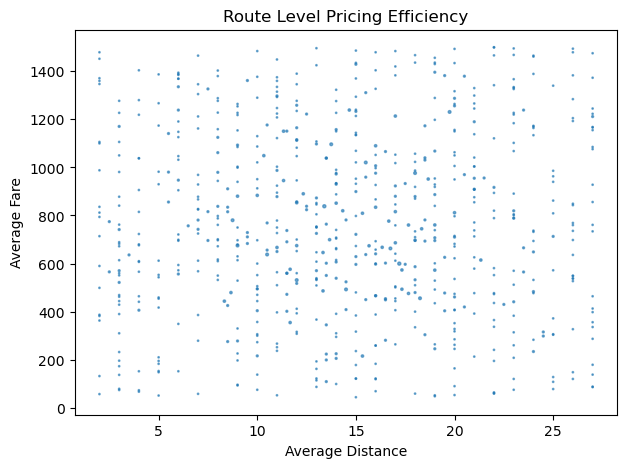

In [285]:
plt.figure(figsize=(7,5))
plt.scatter(
    route_stats['avg_distance'],
    route_stats['avg_fare'],
    s=route_stats['trips'],
    alpha=0.6
)

plt.xlabel("Average Distance")
plt.ylabel("Average Fare")
plt.title("Route Level Pricing Efficiency")
plt.show()

**Note** - The route-level pricing efficiency plot compares average fare against average distance for each route. While a positive relationship between distance and fare is observed, significant variation exists at similar distances. This indicates that route-specific factors influence pricing, highlighting opportunities to identify under-priced and over-performing routes.


   **(4) Average fare by distance by payment method**

C:\Users\p\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


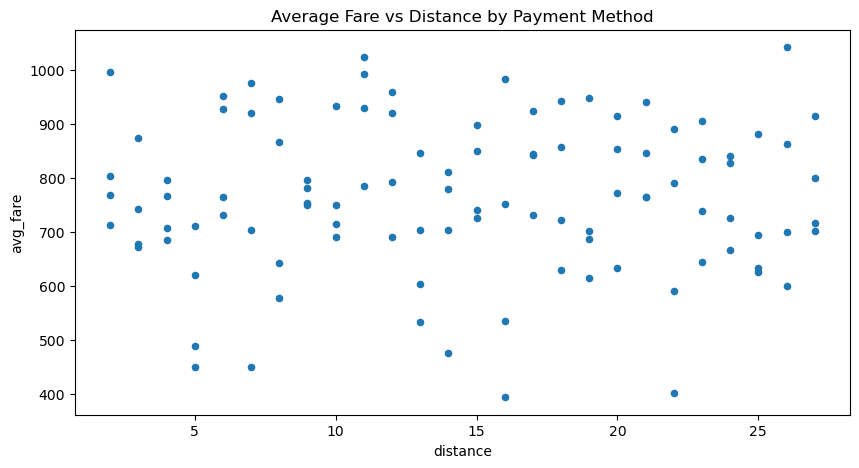

In [359]:
agg_pay = (
    df.groupby(['distance','Faremethod'])
      .agg(avg_fare=('fare','mean'),
           trips=('tripid','count'))
      .reset_index()
)
agg_pay.plot.scatter(x="distance", y="avg_fare", title="Average Fare vs Distance by Payment Method", figsize = (10,5), cmap="plasma")
plt.show()

**Note** - The plot shows the relationship between average fare and distance after aggregating trips by distance and payment method. A clear positive trend is observed, confirming distance-based pricing. Aggregation reduces noise present in raw trip-level data, while remaining variability at similar distances suggests the influence of additional route-level factors.


   **(5) Fare distribbution by distance**

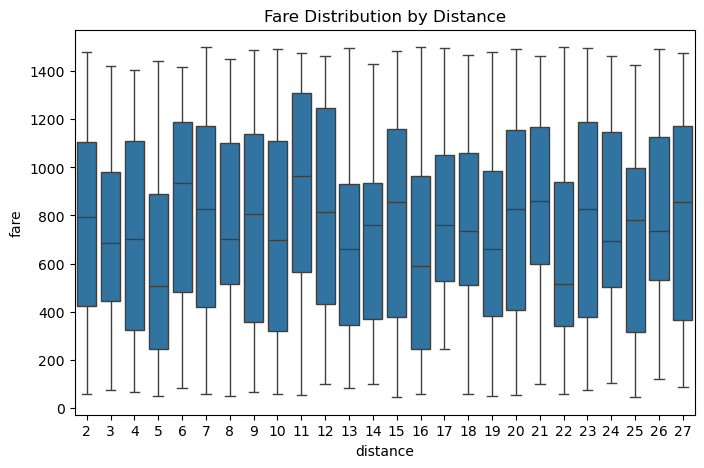

In [341]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='distance',
    y='fare',
    data=df
)
plt.title("Fare Distribution by Distance")
plt.show()

**Note** - The box plot illustrates the distribution of fares across different distance values. While median fare increases with distance, significant variability is observed at each distance level. The overlapping fare ranges suggest that distance alone does not determine fare, highlighting the influence of additional factors such as route and duration.


   **(6) Distance by fare by customer comletion**

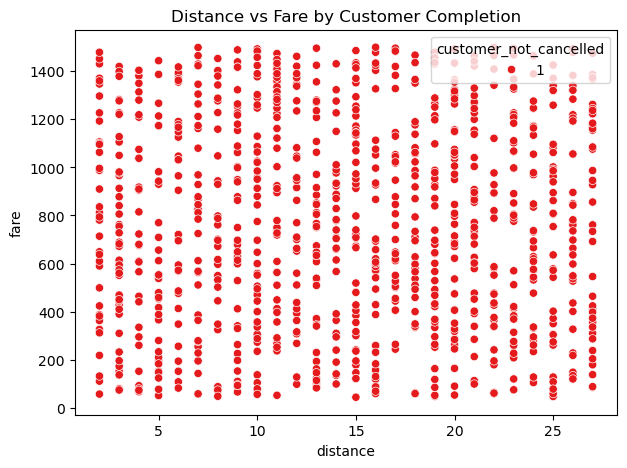

In [327]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='customer_not_cancelled',
    palette='Set1'
)
plt.title("Distance vs Fare by Customer Completion")
plt.show()

**Note** - The scatter plot compares distance and fare for completed and cancelled trips. Both categories exhibit similar patterns, indicating that fare and distance do not significantly influence customer cancellation behavior. The absence of clear separation suggests that cancellations are driven by other operational or behavioral factors.

# **Multivariate visual**


   **(1) Driver trips by revenue by distance**

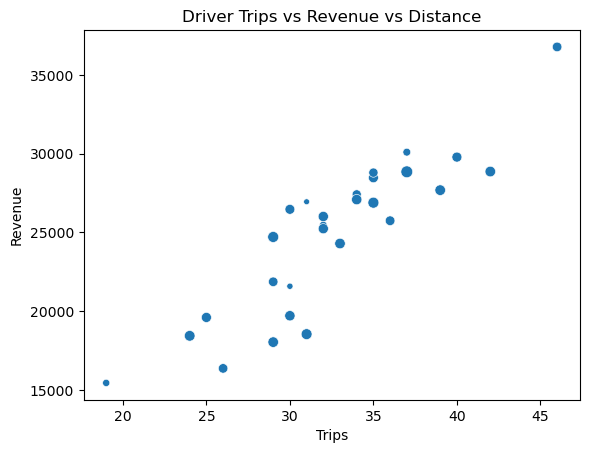

In [317]:
driver_stats = df.groupby('driverid').agg(
    trips=('tripid', 'count'),
    revenue=('fare', 'sum'),
    avg_distance=('distance', 'mean')
)

plt.figure()
sns.scatterplot(
    x=driver_stats['trips'],
    y=driver_stats['revenue'],
    size=driver_stats['avg_distance'],
    legend=False
)
plt.title("Driver Trips vs Revenue vs Distance")
plt.xlabel("Trips")
plt.ylabel("Revenue")
plt.show()

**Note** - The scatter plot illustrates the relationship between the number of trips completed by drivers and the total revenue generated. A strong positive correlation is observed, indicating that drivers who complete more trips earn higher revenue. Variations in revenue at similar trip levels suggest the influence of trip distance and route characteristics


   **(2) Correlation Heatmap**

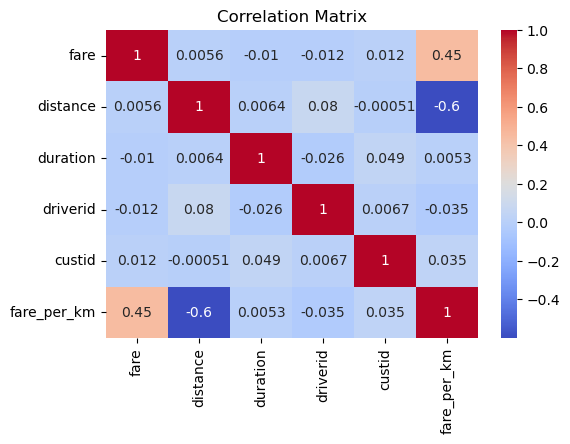

In [315]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[['fare','distance','duration','driverid','custid','fare_per_km']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

**Note** - The correlation matrix shows that fare has a moderate positive correlation with fare per kilometer, while distance and fare per kilometer exhibit a strong negative correlation. This suggests a slab-based pricing structure where per-km charges decrease for longer trips. Duration and identifier variables show negligible correlation, indicating limited influence on fare.

---
## **BUSINESS CONCLUSION :-**

From the above analysis, we could conclude that:

Trip demand is well distributed across locations, with multiple pickup and drop hubs indicating balanced city usage.

Fare generally increases with distance, but varies for similar distances, showing flexible pricing.

Fare per km decreases as distance increases, indicating a slab-based pricing model.

Most trips are short to medium duration, reflecting typical urban travel behavior.

Digital payments dominate (UPI, cards), while cash usage is lowest, showing strong digital adoption.

Fare distribution is consistent across payment methods, confirming payment-neutral pricing.

Route analysis reveals key travel corridors between commercial and residential areas.

Customer cancellations are not driven by fare or distance, suggesting operational factors like wait time influence cancellations.

Driver revenue increases with number of trips, but varies due to route and distance differences.

Overall, business growth can be improved through route optimization, driver efficiency, and cancellation reduction, rather than pricing changes alone.